# EDA - IELTS Writing Task 2 (Hugging Face)

Dataset: `chillies/IELTS-writing-task-2-evaluation`

Muc tieu:
- Kiem tra quality co ban (null/empty/outlier)
- Chuan hoa cot `band`
- Thong ke do dai prompt/essay/evaluation
- Kiem tra duplicate
- Kiem tra tinh template cua cot `evaluation`


## 0) Cai dependencies (neu can)


In [1]:
import sys
!{sys.executable} -m pip install -U datasets pandas numpy matplotlib seaborn


  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached pandas-3.0.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached pyarrow-23.0.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (3.1 kB)
Using cached datasets-4.5.0-py3-none-any.whl (515 kB)
Using cached pandas-3.0.1-cp312-cp312-macosx_11_0_arm64.whl (9.9 MB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached pyarrow-23.0.1-cp312-cp312-macosx_12_0_arm64.whl (34.2 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 16.1.0
    Uninstalling pyarrow-16.1.0:
      Successfully uninstalled pyarrow-16.1.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotl

## 1) Load dataset


In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import hashlib
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 180)

DATASET_NAME = 'chillies/IELTS-writing-task-2-evaluation'
ds = load_dataset(DATASET_NAME)
print(ds)

split_name = list(ds.keys())[0]
df = ds[split_name].to_pandas()
print('split:', split_name)
print('shape:', df.shape)
print('columns:', list(df.columns))

df.head(3)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


train.csv:   0%|          | 0.00/44.5M [00:00<?, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9833 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/491 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'essay', 'evaluation', 'band'],
        num_rows: 9833
    })
    test: Dataset({
        features: ['prompt', 'essay', 'evaluation', 'band'],
        num_rows: 491
    })
})
split: train
shape: (9833, 4)
columns: ['prompt', 'essay', 'evaluation', 'band']


,prompt,essay,evaluation,band
0,"Interviews form the basic criteria for most large companies. However, some people think that the interview is not a reliable method of choosing whom to employ and there are oth...","It is believed by some experts that the traditional approach of recruiting candidates which is interviewing is the best way, whereas others think different methods such as exam...",**Task Achievement: [7]**\nThe essay effectively addresses the given task. The candidate clearly states their position in the introduction and provides relevant arguments and e...,7.5\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
1,"Interviews form the basic selecting criteria for most large companies. However, some people think that the interview is not a reliable method of choosing whom to employ and the...","Nowadays numerous huge firms allocate an interview form as the basic choosing criteria. Whereas, a group of the public believe that this form is no longer up-to-the-minute and ...",**Task Achievement:** 5.0\n- The candidate has effectively addressed the given task by providing a clear and relevant response that covers all aspects of the task.\n- The essay...,5.0\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
2,"Interview form the basic selection criteria for most large companies. However, some people think that interview is not a reliable method of choosing whom to employ and there ar...",The interview section is the most vital part of the hiring process. It is the time for knowing the interviewee and also for the person being interviewed to learn some informati...,## Task Achievement:\n- The candidate has effectively addressed the given task by presenting a clear stance on the reliability of interviews as a method of employee selection a...,5.5\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r


## 2) Kiem tra null/empty + thong ke do dai


In [3]:
expected_cols = ['prompt', 'essay', 'evaluation', 'band']
missing_cols = [c for c in expected_cols if c not in df.columns]
print('missing_cols:', missing_cols)

null_rates = df[expected_cols].isna().mean().sort_values(ascending=False)
print('\nNull rate:')
print(null_rates)

for c in expected_cols:
    empty_rate = df[c].astype(str).str.strip().eq('').mean()
    print(f'empty_rate[{c}] = {empty_rate:.4f}')

def wc(x):
    return len(str(x).split())

df['prompt_words'] = df['prompt'].map(wc)
df['essay_words'] = df['essay'].map(wc)
df['evaluation_words'] = df['evaluation'].map(wc)

display(df[['prompt_words','essay_words','evaluation_words']].describe(percentiles=[0.5,0.9,0.95,0.99]).T)


missing_cols: []

Null rate:
prompt        0.0
essay         0.0
evaluation    0.0
band          0.0
dtype: float64
empty_rate[prompt] = 0.0000
empty_rate[essay] = 0.0000
empty_rate[evaluation] = 0.0000
empty_rate[band] = 0.0000


,count,mean,std,min,50%,90%,95%,99%,max
prompt_words,9833.0,31.849385,7.660713,10.0,32.0,41.0,45.0,53.0,80.0
essay_words,9833.0,292.681989,57.997544,1.0,289.0,356.0,382.4,447.0,1557.0
evaluation_words,9833.0,376.750534,76.022138,101.0,371.0,466.0,501.0,596.0,1458.0


## 3) Parse va phan tich cot band


band parse null rate: 0.0
unique band values: [4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0]


band_value
4.0    1168
4.5     646
5.0    1049
5.5     955
6.0    1143
6.5    1168
7.0    1358
7.5    1105
8.0     700
8.5     433
9.0     108
Name: count, dtype: int64

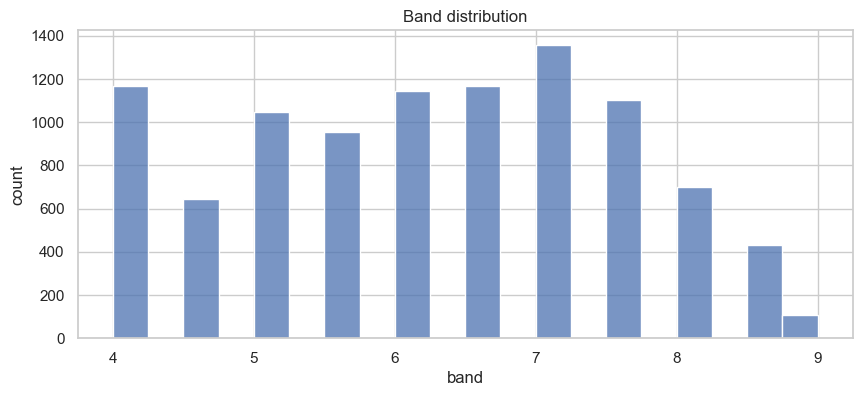

In [4]:
band_re = re.compile(r'(\d(?:\.\d)?)')

def parse_band(x):
    if x is None:
        return np.nan
    s = str(x).strip()
    m = band_re.search(s)
    if not m:
        return np.nan
    try:
        return float(m.group(1))
    except Exception:
        return np.nan

df['band_value'] = df['band'].map(parse_band)
print('band parse null rate:', df['band_value'].isna().mean())
print('unique band values:', sorted(df['band_value'].dropna().unique().tolist()))

band_counts = df['band_value'].value_counts(dropna=False).sort_index()
display(band_counts)

plt.figure(figsize=(10,4))
sns.histplot(df['band_value'].dropna(), bins=20)
plt.title('Band distribution')
plt.xlabel('band')
plt.ylabel('count')
plt.show()


## 4) Duplicate check


In [5]:
def norm_text(s):
    s = str(s)
    s = s.replace('\r\n', '\n').replace('\r', '\n')
    s = re.sub(r'\s+', ' ', s).strip().lower()
    return s

def sha256_text(s):
    return hashlib.sha256(s.encode('utf-8')).hexdigest()

df['prompt_hash'] = df['prompt'].map(norm_text).map(sha256_text)
df['essay_hash'] = df['essay'].map(norm_text).map(sha256_text)

n = len(df)
prompt_unique = df['prompt_hash'].nunique()
essay_unique = df['essay_hash'].nunique()
pair_unique = df[['prompt_hash','essay_hash']].drop_duplicates().shape[0]

print('rows:', n)
print('prompt dup rate:', round(1 - prompt_unique/n, 4))
print('essay dup rate:', round(1 - essay_unique/n, 4))
print('pair dup rate:', round(1 - pair_unique/n, 4))

print('\nTop duplicate prompts:')
display(df['prompt_hash'].value_counts().head(10))

print('Top duplicate essays:')
display(df['essay_hash'].value_counts().head(10))


rows: 9833
prompt dup rate: 0.757
essay dup rate: 0.1071
pair dup rate: 0.1061

Top duplicate prompts:


prompt_hash
f293ff736f8f06b245204b6e7aa1129fcd35e86d697d6a8f3684717bc3a64bbd    387
35e021bf81de89b12a3e900706a78f53af8a5bbfdcd520e793108a5be450a896    172
5c5a1296579ab3ca32ab1796ba43688c93d7469d038b4b69f6cbd8297b555d12    148
5a6e7f422b52c0de75f5ac4d299ad0749fb6fc7d42e87fed7dd001e50447148f    125
95732fc245ba68cc49adbad1dd26a2439cb82aa8ac9bbfc8d727592c2900ca5a    124
c4bbbf5ec3a7d595818b86800772fc25438540126a37620fad097b180e63b91e     88
d9c7ab98de979b36cfe8a6483719d46049a3cb84fa61f533766c54c53e3510c5     88
887e2e5b23521c5efeff1babfae2d4c377e9c24f77ecb8b645f569817b9fc5c9     85
c1871d3876e1b63ca577d08df08bfe87010f42af740c7b117cc2a9d9a7d90761     74
58531f4ab91aca9aca8e60eb4ff118c47908f8adeca55abf3023707a607f10f6     70
Name: count, dtype: int64

Top duplicate essays:


essay_hash
27e6c6765ca4983f3e81393f7309534b159376313e5552eaa86d0c7668b5101e    7
139b01674c22f8e6ac2d141329e1d67f087b666a96687e0b54fa1950cf1fc1a3    6
bf57ed333ba3b905f6b0587b39a4fd63675906a5920433a69f4fe86473295fc7    6
db92525adb8e80f18508a648f435900c94fe5cfdac7df601ec3972e23a4300a6    5
beb47d7cf3a882d7932e05edc30251c28c4790374840ca6b5ab59fb687c16669    5
d37ef57ad96cea075aefa158e71943ec3a86fbb2b9fb96b407392902a4fb2657    4
01dbe0b6593a7dd85606f9e55e636731029121025a04c0f012facb59ec57acc9    4
302374ce3ae4fd87c74867baf8acad3485906189ae1762ae02481b9a0ca88bc9    4
6b0864b952b1a8d900ddca02d904cb233ad349d5db30122a52119c76181df551    3
bbad24055d4678e9195a18ff264fd27adaf09b0695f6729a214108fe3afaa841    3
Name: count, dtype: int64

## 5) Evaluation template check (heuristic)


In [6]:
markers = [
    'Task Achievement', 'Task Response',
    'Coherence and Cohesion',
    'Lexical Resource',
    'Grammatical Range and Accuracy',
    'Overall Band Score',
    'Strengths', 'Areas for Improvement', 'Suggestions', 'Additional Comments'
]

presence = {}
ev = df['evaluation'].astype(str)
for m in markers:
    presence[m] = ev.str.contains(m, case=False, na=False).mean()

presence_df = pd.DataFrame({'marker': list(presence.keys()), 'presence_rate': list(presence.values())})\
    .sort_values('presence_rate', ascending=False)
display(presence_df)

first200 = ev.str.replace(r'\s+', ' ', regex=True).str.strip().str[:200]
fp_counts = first200.value_counts()
print('unique first-200 fingerprints:', fp_counts.shape[0])
display(fp_counts.head(10))

first_line = ev.str.splitlines().map(lambda xs: next((x.strip() for x in xs if x.strip()), ''))
display(first_line.value_counts().head(15))


,marker,presence_rate
0,Task Achievement,1.000000
2,Coherence and Cohesion,1.000000
3,Lexical Resource,1.000000
5,Overall Band Score,0.999898
4,Grammatical Range and Accuracy,0.999593
9,Additional Comments,0.851012
7,Areas for Improvement,0.688498
6,Strengths,0.671006
8,Suggestions,0.195261
1,Task Response,0.001220


unique first-200 fingerprints: 9800


evaluation
## Task Achievement: - The candidate has adequately addressed the given task by providing a clear stance on the topic and supporting it with relevant arguments. - The essay covers all aspects of the t    3
## Task Achievement: - The candidate has effectively addressed the given task. - The ideas presented are clear, relevant, and coherent. - All aspects of the task have been adequately covered and suppo    3
## Task Achievement: - The candidate has effectively addressed the given task by providing a clear stance on the issue and supporting it with relevant arguments. - The essay covers all aspects of the     3
### Task Achievement: The candidate has effectively addressed the given task by clearly stating their position and providing relevant arguments to support it. The essay covers all aspects of the task     3
### Task Achievement: - The candidate has effectively addressed the given task by providing a clear stance on the topic and supporting it with relevant arguments. - 

AttributeError: 'StringMethods' object has no attribute 'splitlines'

## 6) Trich sub-scores (TR/CC/LR/GRA) tu evaluation (optional)


In [7]:
def extract_score(text, aliases):
    t = str(text)
    for alias in aliases:
        patterns = [
            rf'{alias}[^\d]*\[\s*(\d(?:\.\d)?)\s*\]',
            rf'{alias}[^\d]*(\d(?:\.\d)?)'
        ]
        for p in patterns:
            m = re.search(p, t, flags=re.IGNORECASE)
            if m:
                try:
                    return float(m.group(1))
                except Exception:
                    pass
    return np.nan

aliases = {
    'TR': ['Task Achievement', 'Task Response'],
    'CC': ['Coherence and Cohesion', 'Coherence & Cohesion'],
    'LR': ['Lexical Resource', 'Vocabulary'],
    'GRA': ['Grammatical Range and Accuracy', 'Grammar']
}

for k, v in aliases.items():
    df[f'{k}_score'] = df['evaluation'].map(lambda x: extract_score(x, v))

display(df[['TR_score','CC_score','LR_score','GRA_score']].describe().T)
display(df[['band_value','TR_score','CC_score','LR_score','GRA_score']].corr(numeric_only=True))


,count,mean,std,min,25%,50%,75%,max
TR_score,9833.0,5.963236,1.538394,0.0,5.0,6.5,7.0,9.0
CC_score,9833.0,5.790298,1.693229,0.0,5.0,6.0,7.0,9.0
LR_score,9832.0,5.498088,1.592345,0.0,5.0,6.0,6.5,9.0
GRA_score,9829.0,5.418425,1.649553,0.0,4.0,6.0,6.5,9.0


,band_value,TR_score,CC_score,LR_score,GRA_score
band_value,1.000000,0.815145,0.775552,0.756130,0.747549
TR_score,0.815145,1.000000,0.942203,0.890838,0.880536
CC_score,0.775552,0.942203,1.000000,0.903273,0.894551
LR_score,0.756130,0.890838,0.903273,1.000000,0.937638
GRA_score,0.747549,0.880536,0.894551,0.937638,1.000000


## 7) Ket luan va xuat data cleaned (optional)


In [8]:
summary = {
    'rows': len(df),
    'band_parse_null_rate': float(df['band_value'].isna().mean()),
    'prompt_dup_rate': float(1 - df['prompt_hash'].nunique()/len(df)),
    'essay_dup_rate': float(1 - df['essay_hash'].nunique()/len(df))
}
summary


{'rows': 9833,
 'band_parse_null_rate': 0.0,
 'prompt_dup_rate': 0.757042611613953,
 'essay_dup_rate': 0.10708837587714837}